
📈 3-ҚАДАМ ЕСЕБІ: SQL Аналитикасы сәтті орындалды және Excel-ге жазылды!



C:\Users\USER\AppData\Local\Temp\ipykernel_14368\2216340834.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


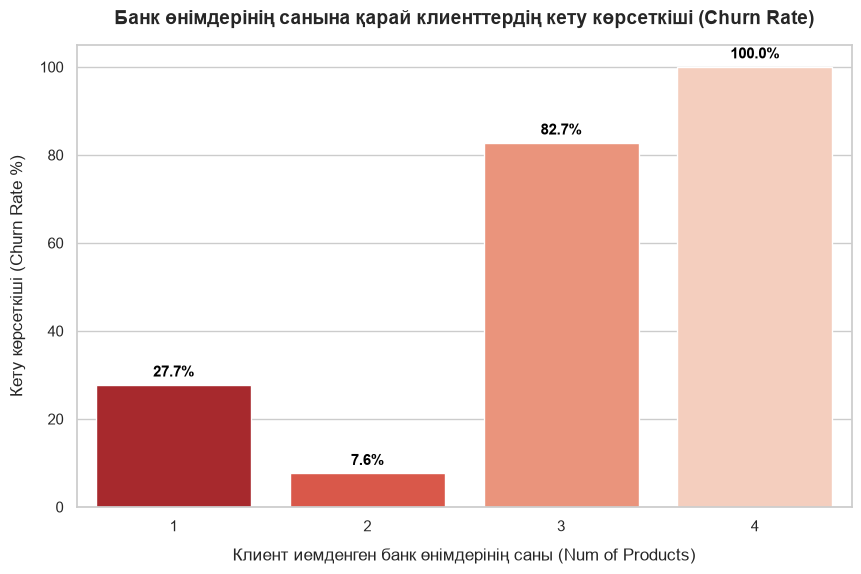

,num_products,total_customers,churned_customers,churn_rate_percentage
0,1,5084,1409,27.7
1,2,4590,348,7.6
2,3,266,220,82.7
3,4,60,60,100.0


In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Базаға қосылу және SQL сұранысын орындау
conn = sqlite3.connect('bank_analytics.db')

query = """
SELECT num_products, 
       COUNT(customer_id) as total_customers, 
       SUM(churn) as churned_customers,
       ROUND(AVG(churn) * 100, 1) as churn_rate_percentage
FROM cleaned_customers
GROUP BY num_products;
"""

df_analysis = pd.read_sql_query(query, conn)
conn.close()

# 2. Аналитика қорытындысын Excel есепке жазу
df_analysis.to_excel('bank_churn_report.xlsx', index=False)

print("\n" + "="*50)
print("📈 3-ҚАДАМ ЕСЕБІ: SQL Аналитикасы сәтті орындалды және Excel-ге жазылды!")
print("="*50 + "\n")

# 3. НАҒЫЗ КӘСИБИ ГРАФИК СЫЗУ БӨЛІМІ
# Графиктің стилін және көлемін белгілеу
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Барлық өнімдер бойынша клиенттердің кету пайызын көрсететін бағандық график (Barplot)
ax = sns.barplot(
    x='num_products', 
    y='churn_rate_percentage', 
    data=df_analysis, 
    palette='Reds_r' # Кету қаупі жоғары болғандықтан қызыл түстер палитрасы
)

# Графиктің тақырыптарын безендіру
plt.title('Банк өнімдерінің санына қарай клиенттердің кету көрсеткіші (Churn Rate)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Клиент иемденген банк өнімдерінің саны (Num of Products)', fontsize=12, labelpad=10)
plt.ylabel('Кету көрсеткіші (Churn Rate %)', fontsize=12, labelpad=10)

# Әр бағанның төбесіне нақты пайыздық санын жазып қою (Көрнекілік үшін)
for p in ax.patches:
    ax.annotate(f"{p.get_height()}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold', color='black')

# 4. Графикті сурет форматында папкаға автоматты сақтау
plt.savefig('bank_churn_chart.png', dpi=300, bbox_inches='tight')

# Графикті экранға шығару
plt.show()

# SQL кестесін де астында көрсету
df_analysis

In [1]:
import sqlite3
import pandas as pd
import numpy as np

# 1. Базамызға қосыламыз
conn = sqlite3.connect('bank_analytics.db')

# 2. Базадан тазаланған клиенттердің ID нөмірлерін оқимыз
df_customers = pd.read_sql_query("SELECT customer_id FROM cleaned_customers", conn)
customer_ids = df_customers['customer_id'].tolist()

# 3. Әр клиентке жасанды 2 транзакциядан (ақша құрту тарихын) құрастырамыз
np.random.seed(42)
tx_data = {
    'transaction_id': range(100001, 100001 + len(customer_ids) * 2),
    'customer_id': np.repeat(customer_ids, 2),
    'amount': np.round(np.random.uniform(10, 5000, len(customer_ids) * 2), 2),
    'category': np.random.choice(['Supermarket', 'Apparel', 'Electronics', 'Cafe', 'Gas Station'], len(customer_ids) * 2),
    'tx_date': np.random.choice(pd.date_range('2026-01-01', '2026-06-01'), len(customer_ids) * 2)
}

df_tx = pd.DataFrame(tx_data)
df_tx['tx_date'] = df_tx['tx_date'].dt.strftime('%Y-%m-%d')

# 4. Осы транзакцияларды базаға жаңа кесте қылып жазамыз
df_tx.to_sql('transactions', conn, if_exists='replace', index=False)
conn.close()

print("Дайын! Базаға 'transactions' деген жаңа кесте қосылды. Енді JOIN жасауға болады!")

Дайын! Базаға 'transactions' деген жаңа кесте қосылды. Енді JOIN жасауға болады!


In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('bank_analytics.db')

# Екі кестені INNER JOIN арқылы біріктіру сұранысы
query = """
SELECT 
    c.customer_id,
    c.surname,
    c.geography,
    t.amount,
    t.category,
    t.tx_date
FROM cleaned_customers c
INNER JOIN transactions t ON c.customer_id = t.customer_id
LIMIT 5;
"""

df_join = pd.read_sql_query(query, conn)
conn.close()
print(df_join)

   customer_id   surname geography   amount     category     tx_date
0     15634602  Hargrave    France  1878.96      Apparel  2026-03-16
1     15634602  Hargrave    France  4754.06         Cafe  2026-03-21
2     15647311      Hill     Spain  2997.31  Gas Station  2026-04-12
3     15647311      Hill     Spain  3662.65  Gas Station  2026-01-18
4     15619304      Onio    France   788.41  Supermarket  2026-02-22


In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('bank_analytics.db')

# Жолдарды жоймай, әр клиенттің жеке терезесінде есептеу жасау
query = """
SELECT 
    c.customer_id,
    c.surname,
    t.amount,
    t.category,
    -- Мынау әр клиенттің өз ішіндегі транзакцияларының жалпы қосындысы (Терезе)
    SUM(t.amount) OVER(PARTITION BY c.customer_id) as total_customer_spend
FROM cleaned_customers c
INNER JOIN transactions t ON c.customer_id = t.customer_id
LIMIT 5;
"""

df_window = pd.read_sql_query(query, conn)
conn.close()
print(df_window)

   customer_id   surname   amount     category  total_customer_spend
0     15565701     Ferri  1137.88         Cafe               4343.86
1     15565701     Ferri  3205.98  Supermarket               4343.86
2     15565706  Akobundu  2255.06  Supermarket               5207.81
3     15565706  Akobundu  2952.75         Cafe               5207.81
4     15565714  Cattaneo   480.17      Apparel               2062.95
